# Homework 2 — DSCI 552

**Name:** Chen Zhu  
**GitHub Username:** ChenZhu50  
**USC ID:** 2370790492

In [1]:
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

%matplotlib inline

## 1. Combined Cycle Power Plant Data Set

> The dataset contains data points collected from a Combined Cycle Power Plant over 6 years (2006–2011), when the power plant was set to work with full load. Features consist of hourly average ambient variables Temperature (T), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V) to predict the net hourly electrical energy output (EP) of the plant.

### 1(a) Question

> Download the Combined Cycle Power Plant data from:  
> https://archive.ics.uci.edu/ml/datasets/Combined+Cycle+Power+Plant

In [2]:
data = pd.read_excel("../data/Folds5x2_pp.xlsx", sheet_name="Sheet1")
predictors = ["AT", "V", "AP", "RH"]
response = "PE"
display(data.head())

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


**Answer:** Loaded `Sheet1` of the UCI workbook (9,568 rows, 5 columns). In the file, temperature is named `AT` and electrical output is named `PE` (T and EP in the question).

### 1(b) Question — Exploring the data

> i. How many rows are in this data set? How many columns? What do the rows and columns represent?

> ii. Make pairwise scatterplots of all the varianbles in the data set including the predictors (independent variables) with the dependent variable. Describe your findings.

> iii. What are the mean, the median, range, first and third quartiles, and interquartile ranges of each of the variables in the dataset? Summarize them in a table.

In [3]:
print(f"Rows: {data.shape[0]:,}; columns: {data.shape[1]}")
print("Missing values by column:")
display(data.isna().sum().rename("Missing"))

Rows: 9,568; columns: 5
Missing values by column:


AT    0
V     0
AP    0
RH    0
PE    0
Name: Missing, dtype: int64

**Answer (i):** The data set has **9,568 rows** and **5 columns**, with no missing values. Each row is one hourly observation: the hourly averages of the ambient conditions and the plant's net electrical output, recorded between 2006 and 2011 while the plant ran at full load. The columns are:

| Column | Meaning | Unit | Role |
|---|---|---|---|
| `AT` | Ambient temperature | °C | Predictor |
| `V` | Exhaust vacuum | cm Hg | Predictor |
| `AP` | Ambient pressure | millibar | Predictor |
| `RH` | Relative humidity | % | Predictor |
| `PE` | Net hourly electrical energy output | MW | Response |

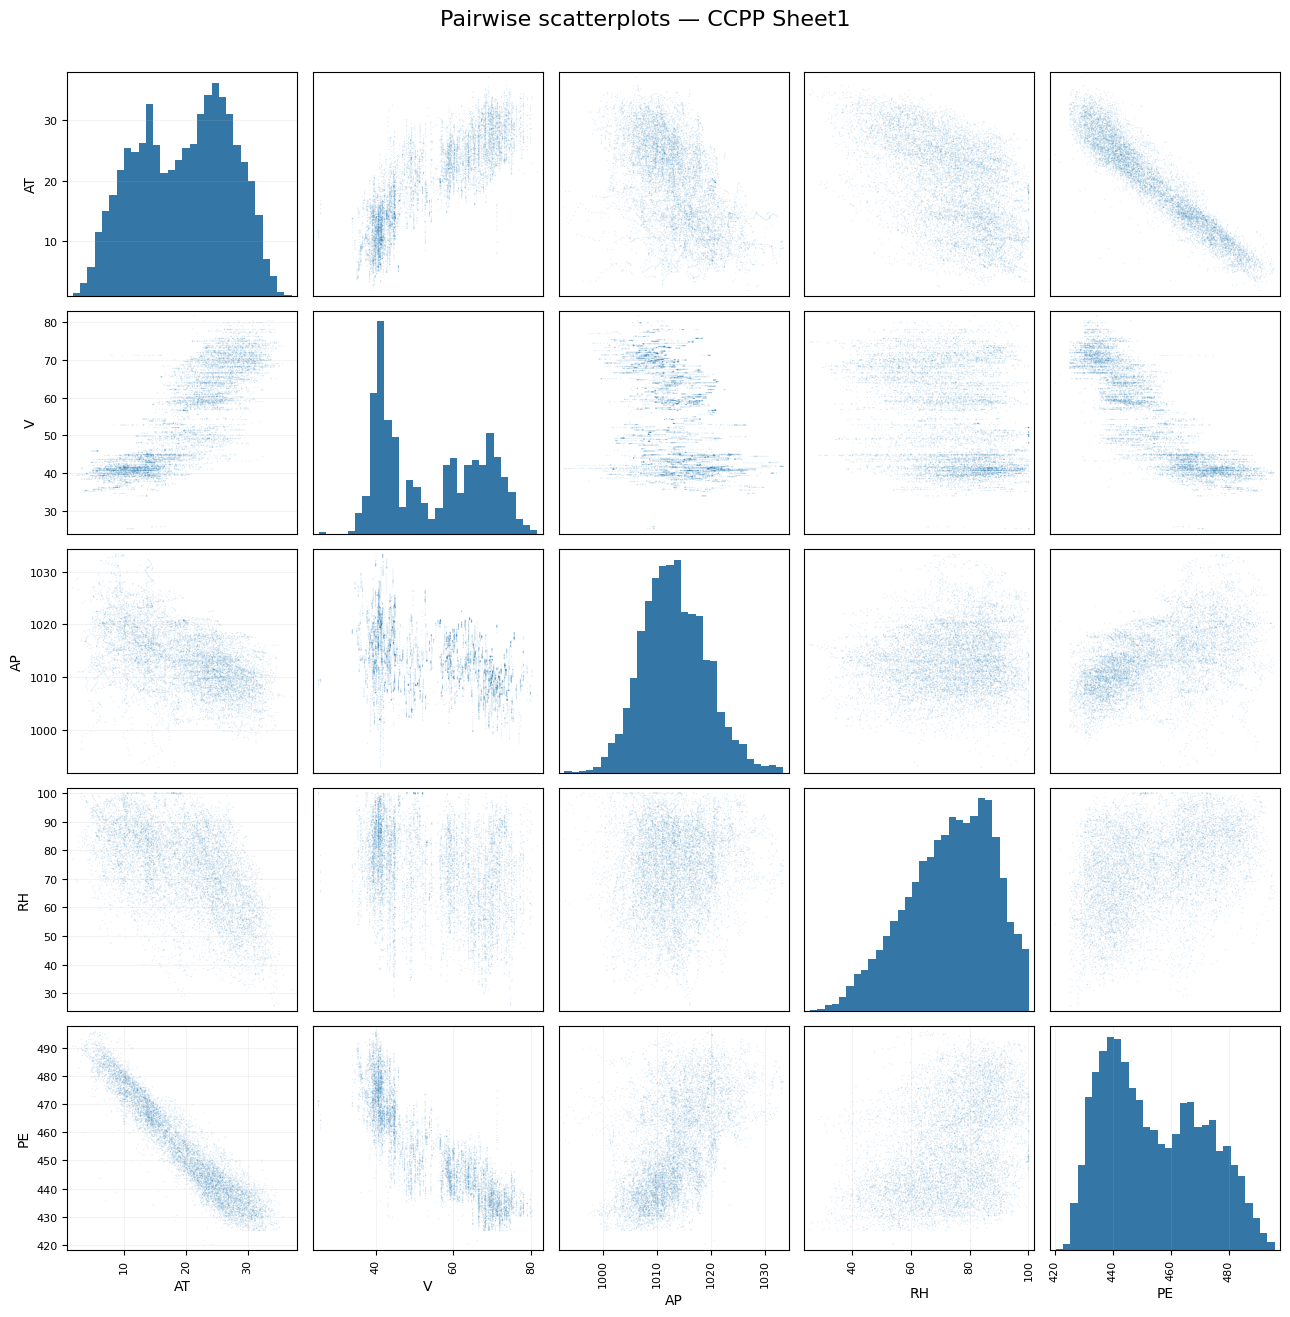

,AT,V,AP,RH,PE
AT,1.000,0.844,-0.508,-0.543,-0.948
V,0.844,1.000,-0.414,-0.312,-0.870
AP,-0.508,-0.414,1.000,0.100,0.518
RH,-0.543,-0.312,0.100,1.000,0.390
PE,-0.948,-0.870,0.518,0.390,1.000


In [4]:
axes = pd.plotting.scatter_matrix(
    data[["AT", "V", "AP", "RH", "PE"]],
    figsize=(13, 13),
    diagonal="hist",
    alpha=0.14,
    s=3,
    hist_kwds={"bins": 30, "color": "#3477a6"},
)
for ax in np.asarray(axes).ravel():
    ax.grid(alpha=0.15)
plt.suptitle("Pairwise scatterplots — CCPP Sheet1", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()
display(data.corr().round(3))

**Answer (ii):**

- **`AT` vs `PE`:** the strongest relationship, strongly negative and close to linear ($r=-0.948$) with little scatter, though there is mild curvature at the ends.
- **`V` vs `PE`:** also strongly negative ($r=-0.870$), but the points form vertical bands because `V` is concentrated around certain values (its histogram has a sharp spike near 40 cm Hg).
- **`AP` vs `PE`:** moderately positive ($r=0.518$) with a lot of scatter.
- **`RH` vs `PE`:** weakly positive ($r=0.390$); the cloud of points is very diffuse.
- **Among the predictors:** `AT` and `V` are strongly correlated ($r=0.844$), so their effects will be hard to separate in a multiple regression. `AT` is also moderately negatively correlated with `AP` ($r=-0.508$) and `RH` ($r=-0.543$).
- **Distributions:** `AT`, `V`, and `PE` are bimodal, `AP` is roughly symmetric, and `RH` is left-skewed (it is capped near 100%).

In [5]:
summary = pd.DataFrame(index=data.columns)
summary["Mean"] = data.mean()
summary["Median"] = data.median()
summary["Min"] = data.min()
summary["Max"] = data.max()
summary["Range (max-min)"] = summary["Max"] - summary["Min"]
summary["Q1"] = data.quantile(0.25)
summary["Q3"] = data.quantile(0.75)
summary["IQR"] = summary["Q3"] - summary["Q1"]
display(summary.round(2))

,Mean,Median,Min,Max,Range (max-min),Q1,Q3,IQR
AT,19.65,20.34,1.81,37.11,35.30,13.51,25.72,12.21
V,54.31,52.08,25.36,81.56,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,992.89,1033.30,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,25.56,100.16,74.60,63.33,84.83,21.50
PE,454.37,451.55,420.26,495.76,75.50,439.75,468.43,28.68


**Answer (iii):** `Range = Max - Min`; `IQR = Q3 - Q1`.

| Variable | Mean | Median | Min–max | Range | Q1 | Q3 | IQR |
|---|---|---|---|---|---|---|---|
| AT | 19.65 | 20.34 | 1.81–37.11 | 35.30 | 13.51 | 25.72 | 12.21 |
| V | 54.31 | 52.08 | 25.36–81.56 | 56.20 | 41.74 | 66.54 | 24.80 |
| AP | 1013.26 | 1012.94 | 992.89–1033.30 | 40.41 | 1009.10 | 1017.26 | 8.16 |
| RH | 73.31 | 74.97 | 25.56–100.16 | 74.60 | 63.33 | 84.83 | 21.50 |
| PE | 454.37 | 451.55 | 420.26–495.76 | 75.50 | 439.75 | 468.43 | 28.68 |

### 1(c) Question

> For each predictor, fit a simple linear regression model to predict the response. Describe your results. In which of the models is there a statistically significant association between the predictor and the response? Create some plots to back up your assertions. Are there any outliers that you would like to remove from your data for each of these regression tasks?

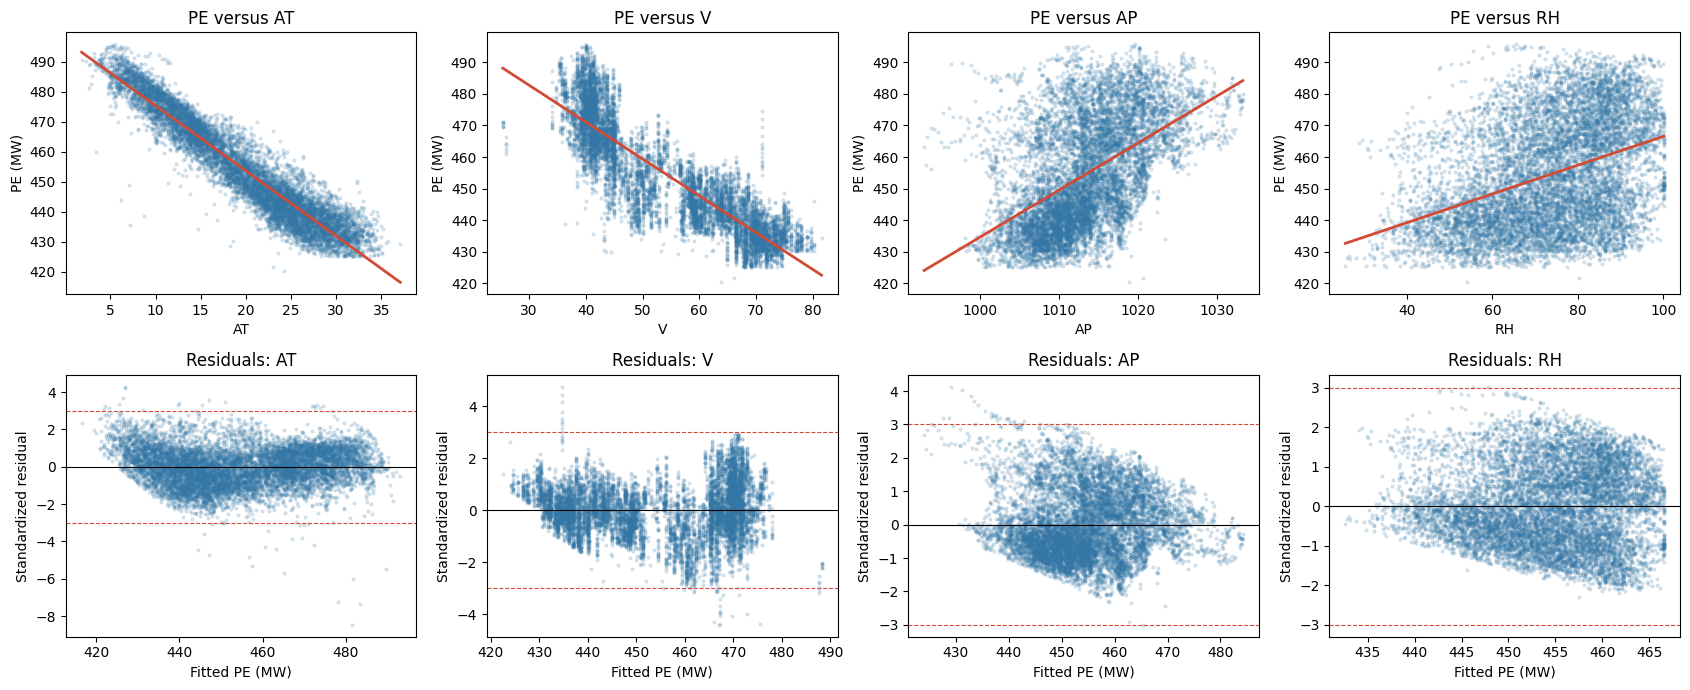

,Intercept,Slope,Slope p-value,R²,|standardized residual| > 3,Slope without them
Predictor,,,,,,
AT,497.0341,-2.1713,0.0,0.8989,42,-2.1802
V,517.8015,-1.1681,0.0,0.7565,33,-1.1769
AP,-1055.2610,1.4899,0.0,0.2688,29,1.5390
RH,420.9618,0.4557,0.0,0.1519,2,0.4564


In [6]:
simple_models = {}
simple_results = []
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for col, var in enumerate(predictors):
    model = sm.OLS(data[response], sm.add_constant(data[[var]])).fit()
    simple_models[var] = model
    standardized_resid = model.get_influence().resid_studentized_internal
    n_extreme = int((np.abs(standardized_resid) > 3).sum())
    keep = np.abs(standardized_resid) <= 3
    refit = sm.OLS(data[response][keep], sm.add_constant(data[[var]][keep])).fit()
    simple_results.append({
        "Predictor": var,
        "Intercept": model.params["const"],
        "Slope": model.params[var],
        "Slope p-value": model.pvalues[var],
        "R²": model.rsquared,
        "|standardized residual| > 3": n_extreme,
        "Slope without them": refit.params[var],
    })

    x = data[var].to_numpy()
    y = data[response].to_numpy()
    grid = np.linspace(x.min(), x.max(), 200)
    axes[0, col].scatter(x, y, s=4, alpha=0.16, color="#3477a6")
    axes[0, col].plot(grid, model.params["const"] + model.params[var] * grid,
                      color="#d14b36", linewidth=2)
    axes[0, col].set(xlabel=var, ylabel="PE (MW)", title=f"PE versus {var}")
    axes[1, col].scatter(model.fittedvalues, standardized_resid,
                         s=4, alpha=0.16, color="#3477a6")
    axes[1, col].axhline(0, color="black", linewidth=0.8)
    axes[1, col].axhline(3, color="#d14b36", linewidth=0.8, linestyle="--")
    axes[1, col].axhline(-3, color="#d14b36", linewidth=0.8, linestyle="--")
    axes[1, col].set(xlabel="Fitted PE (MW)", ylabel="Standardized residual",
                      title=f"Residuals: {var}")
plt.tight_layout()
plt.show()
simple_results = pd.DataFrame(simple_results).set_index("Predictor")
display(simple_results.round(4))

**Answer:** All four slopes are statistically significant ($p<0.001$; the p-values are so small that they underflow to 0 in floating point), so **each predictor on its own has a significant association with `PE`**. `AT` explains the most variation ($R^2=0.899$), followed by `V` ($R^2=0.757$), while `AP` ($0.269$) and `RH` ($0.152$) explain much less. For example, each 1 °C increase in `AT` lowers the predicted output by about 2.17 MW.

| Predictor | Slope | Slope p-value | R² | \|standardized residual\| > 3 | Slope without them | Remove? |
|---|---|---|---|---|---|---|
| AT | -2.171 | < 1e-300 | 0.899 | 42 | -2.180 | No |
| V | -1.168 | < 1e-300 | 0.757 | 33 | -1.177 | No |
| AP | 1.490 | < 1e-300 | 0.269 | 29 | 1.539 | No |
| RH | 0.456 | < 1e-300 | 0.152 | 2 | 0.456 | No |

**Plots:** the fitted line follows the `AT` cloud closely, the `V` points sit in bands around the line, and the `AP` and `RH` clouds are spread widely around their lines, which matches the $R^2$ values. The residual plots also show structure that a straight line misses: mild curvature for `AT`, banded clusters for `V`, and uneven spread for `AP`. This suggests nonlinear terms (1(f)–(h)).

**Outliers:** Only a small fraction of points (at most 42 of 9,568, under 0.5%) have $|$standardized residual$|>3$. The most extreme is about $-8.5$ in the `AT` model. All of these values lie within physically plausible ranges, and removing them changes the slopes by less than 1% for `AT`, `V`, and `RH` and by about 3% for `AP`. Since there is no evidence of recording errors, I would **not** remove them from any of the four regressions.

### 1(d) Question

> Fit a multiple regression model to predict the response using all of the predictors. Describe your results. For which predictors can we reject the null hypothesis $H_0: \beta_j=0$?

In [7]:
multiple_model = sm.OLS(data[response], sm.add_constant(data[predictors])).fit()
multiple_results = pd.DataFrame({
    "Coefficient": multiple_model.params,
    "p-value": multiple_model.pvalues,
    "95% CI lower": multiple_model.conf_int()[0],
    "95% CI upper": multiple_model.conf_int()[1],
})
display(multiple_results.round(6))
print(f"R² = {multiple_model.rsquared:.4f}; adjusted R² = {multiple_model.rsquared_adj:.4f}")

,Coefficient,p-value,95% CI lower,95% CI upper
const,454.609274,0.0,435.500123,473.718425
AT,-1.977513,0.0,-2.007483,-1.947543
V,-0.233916,0.0,-0.248191,-0.219642
AP,0.062083,0.0,0.043543,0.080623
RH,-0.158054,0.0,-0.166225,-0.149883


R² = 0.9287; adjusted R² = 0.9287


**Answer:** Together the four predictors explain **92.9%** of the variance in `PE` ($R^2=0.9287$), which is more than the best single predictor (`AT`, $R^2=0.899$). Holding the other predictors fixed, a 1 °C increase in `AT` lowers the predicted output by about 1.98 MW, and higher `V` and `RH` are also associated with lower output, while higher `AP` is associated with slightly higher output. All four p-values are far below 0.05, so **we can reject $H_0:\beta_j=0$ for `AT`, `V`, `AP`, and `RH`**, in each case conditional on the other predictors.

| Predictor | Coefficient | p-value |
|---|---|---|
| AT | -1.978 | < 1e-300 |
| V | -0.234 | 4.38e-215 |
| AP | 0.062 | 5.51e-11 |
| RH | -0.158 | 3.10e-293 |

### 1(e) Question

> How do your results from 1c compare to your results from 1d? Create a plot displaying the univariate regression coefficients from 1c on the x-axis, and the multiple regression coefficients from 1d on the y-axis. That is, each predictor is displayed as a single point in the plot. Its coefficient in a simple linear regression model is shown on the x-axis, and its coefficient estimate in the multiple linear regression model is shown on the y-axis.

,Simple regression,Multiple regression
AT,-2.1713,-1.9775
V,-1.1681,-0.2339
AP,1.4899,0.0621
RH,0.4557,-0.1581


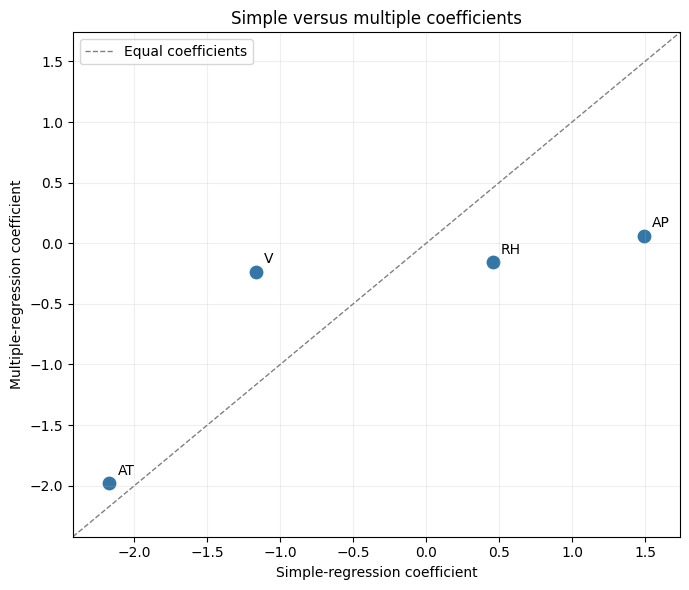

In [8]:
coefficient_comparison = pd.DataFrame({
    "Simple regression": [simple_models[v].params[v] for v in predictors],
    "Multiple regression": [multiple_model.params[v] for v in predictors],
}, index=predictors)
display(coefficient_comparison.round(4))
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(coefficient_comparison["Simple regression"],
           coefficient_comparison["Multiple regression"], s=80, color="#3477a6")
for name, row in coefficient_comparison.iterrows():
    ax.annotate(name, (row["Simple regression"], row["Multiple regression"]),
                xytext=(6, 6), textcoords="offset points")
lim = [coefficient_comparison.min().min() - 0.25,
       coefficient_comparison.max().max() + 0.25]
ax.plot(lim, lim, linestyle="--", linewidth=1, color="gray", label="Equal coefficients")
ax.set(xlim=lim, ylim=lim, xlabel="Simple-regression coefficient",
       ylabel="Multiple-regression coefficient", title="Simple versus multiple coefficients")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Answer:** All four predictors are significant in both 1(c) and 1(d), but their coefficients change a lot once the others are included. On the plot, only `AT` lies near the dashed line of equal coefficients.

| Predictor | Simple regression | Multiple regression |
|---|---|---|
| AT | -2.171 | -1.978 |
| V | -1.168 | -0.234 |
| AP | 1.490 | 0.062 |
| RH | 0.456 | -0.158 |

- **`AT`** stays almost the same, because it is the dominant driver of `PE`.
- **`V`** shrinks by about 80%. `V` is strongly correlated with `AT` ($r=0.844$), so in the simple regression, much of `V`'s apparent effect is really the effect of temperature.
- **`AP`** shrinks almost to zero for the same reason: it is correlated with `AT` ($r=-0.508$), and in the simple regression high pressure partly stands in for low temperature.
- **`RH`** changes sign, from positive to negative. `RH` is negatively correlated with `AT` ($r=-0.543$), so on its own, high humidity partly indicates cool hours, when output is high. Once temperature is held fixed, higher humidity is associated with slightly *lower* output.

In short, the simple-regression coefficients mix each predictor's own effect with the effects of the correlated predictors, mainly `AT`.

### 1(f) Question

> Is there evidence of nonlinear association between any of the predictors and the response? To answer this question, for each predictor $X$, fit a model of the form $Y=\beta_0+\beta_1X+\beta_2X^2+\beta_3X^3+\epsilon$.

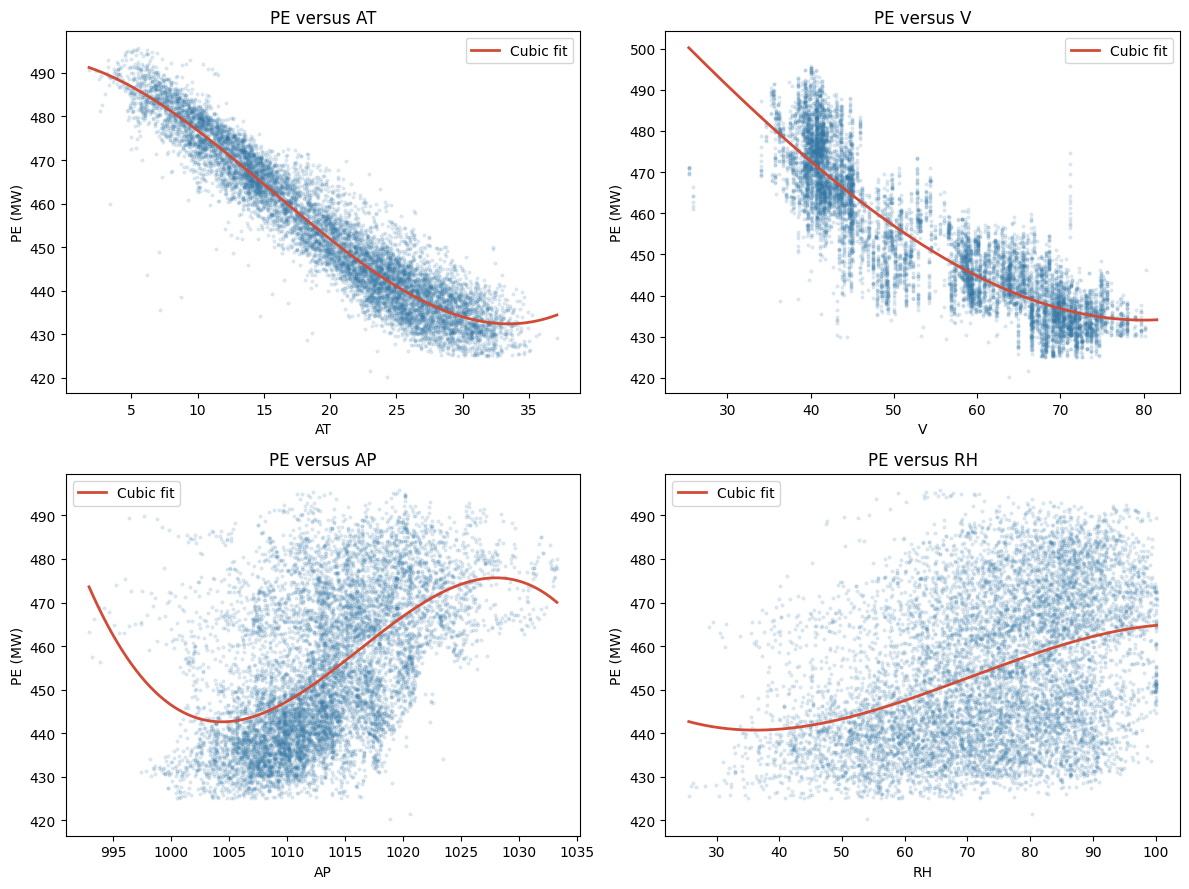

,p(z²),p(z³),Joint p(z²=z³=0),Cubic R²,ΔR² vs linear
Predictor,,,,,
AT,3.311808e-231,3.652185e-110,3.478379e-285,0.911883,0.012935
V,8.977010e-131,1.373489e-02,7.040304e-165,0.775022,0.018504
AP,2.192722e-46,2.123338e-67,4.209145e-84,0.297543,0.028775
RH,1.013949e-01,1.440279e-05,3.799622e-05,0.153743,0.001803


In [9]:
cubic_models = {}
cubic_results = []
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, var in zip(axes.flat, predictors):
    x = data[var]
    center, scale = x.mean(), x.std(ddof=0)
    z = (x - center) / scale
    terms = pd.DataFrame({"z": z, "z²": z ** 2, "z³": z ** 3})
    cubic = sm.OLS(data[response], sm.add_constant(terms)).fit()
    cubic_models[var] = cubic
    f_stat, joint_p, df_diff = cubic.compare_f_test(simple_models[var])
    cubic_results.append({
        "Predictor": var,
        "p(z²)": cubic.pvalues["z²"],
        "p(z³)": cubic.pvalues["z³"],
        "Joint p(z²=z³=0)": joint_p,
        "Cubic R²": cubic.rsquared,
        "ΔR² vs linear": cubic.rsquared - simple_models[var].rsquared,
    })
    grid = np.linspace(x.min(), x.max(), 300)
    zg = (grid - center) / scale
    grid_terms = pd.DataFrame({"z": zg, "z²": zg ** 2, "z³": zg ** 3})
    prediction = cubic.predict(sm.add_constant(grid_terms))
    ax.scatter(x, data[response], s=4, alpha=0.12, color="#3477a6")
    ax.plot(grid, prediction, color="#d14b36", linewidth=2, label="Cubic fit")
    ax.set(xlabel=var, ylabel="PE (MW)", title=f"PE versus {var}")
    ax.legend()
plt.tight_layout()
plt.show()
cubic_results = pd.DataFrame(cubic_results).set_index("Predictor")
display(cubic_results)

**Answer:** **Yes.** The joint F-test of the quadratic and cubic terms (comparing each cubic model with its linear model) rejects linearity for all four predictors ($p<0.05$). For `AT` and `AP`, the cubic term is also individually highly significant. For `RH`, however, the evidence is statistically significant but practically small: $R^2$ improves by only 0.002.

| Predictor | p(z²) | p(z³) | Joint p(z²=z³=0) | Cubic R² | ΔR² vs linear |
|---|---|---|---|---|---|
| AT | 3.31e-231 | 3.65e-110 | 3.48e-285 | 0.9119 | 0.0129 |
| V | 8.98e-131 | 1.37e-02 | 7.04e-165 | 0.7750 | 0.0185 |
| AP | 2.19e-46 | 2.12e-67 | 4.21e-84 | 0.2975 | 0.0288 |
| RH | 1.01e-01 | 1.44e-05 | 3.80e-05 | 0.1537 | 0.0018 |

**Why standardize:** Because `AP` is around 1000, $AP^3$ is around $10^9$, which makes the raw design matrix numerically rank-deficient and gives an incorrect fit. So I fit the cubic in $z=(X-\bar X)/s_X$. A cubic in $z$ is the same model as a cubic in $X$ (same fitted values and $R^2$), and both the p-value of the cubic term and the joint F-test are unchanged by this rescaling. The p-values of the lower-order terms ($z$, $z^2$) do depend on centering, so my conclusions are based on the joint F-test and p(z³).

### 1(g) Question

> Is there evidence of association of interactions of predictors with the response? To answer this question, run a full linear regression model with all pairwise interaction terms and state whether any interaction terms are statistically significant.

In [10]:
pairs = list(combinations(predictors, 2))

def build_features(frame, center, quadratic=False):
    x = frame[predictors] - center
    result = x.copy()
    if quadratic:
        for name in predictors:
            result[f"{name}^2"] = x[name] ** 2
    for a, b in pairs:
        result[f"{a}:{b}"] = x[a] * x[b]
    return result

X_g = build_features(data, data[predictors].mean())
interaction_model = sm.OLS(data[response], sm.add_constant(X_g)).fit()
interaction_names = [f"{a}:{b}" for a, b in pairs]
g_results = pd.DataFrame({
    "Coefficient": interaction_model.params[interaction_names],
    "p-value": interaction_model.pvalues[interaction_names],
    "Significant (5%)": interaction_model.pvalues[interaction_names] < 0.05,
})
display(g_results)
f_stat, joint_p, _ = interaction_model.compare_f_test(multiple_model)
print(f"R² = {interaction_model.rsquared:.4f}; joint interaction p-value = {joint_p:.3g}")

,Coefficient,p-value,Significant (5%)
AT:V,0.020971,3.333358e-117,True
AT:AP,0.001759,4.520509e-01,False
AT:RH,-0.005230,1.216944e-10,True
V:AP,0.006812,2.877026e-07,True
V:RH,0.000839,8.619366e-02,False
AP:RH,-0.001612,3.360557e-02,True


R² = 0.9363; joint interaction p-value = 8.06e-230


**Answer:** **Yes.** Four of the six pairwise interactions are significant at the 5% level, and the joint F-test of all six interaction terms is highly significant ($p=8.1\times10^{-230}$). Adding the interactions raises $R^2$ from 0.9287 to 0.9363. The predictors are centered before the products are formed, which reduces collinearity; this does not change the interaction coefficients or their tests, because the interactions are the highest-order terms in the model.

| Interaction | p-value | Significant at 5%? |
|---|---:|---|
| `AT:V` | 3.3e-117 | Yes |
| `AT:AP` | 0.45 | No |
| `AT:RH` | 1.2e-10 | Yes |
| `V:AP` | 2.9e-07 | Yes |
| `V:RH` | 0.086 | No |
| `AP:RH` | 0.034 | Yes |

### 1(h) Question

> Can you improve your model using possible interaction terms or nonlinear associations between the predictors and response? Train the regression model on a randomly selected 70% subset of the data with all predictors. Also, run a regression model involving all possible interaction terms and quadratic nonlinearities, and remove insignificant variables using p-values (be careful about interaction terms). Test both models on the remaining points and report your train and test MSEs.

In [11]:
train, test = train_test_split(data, train_size=0.70, random_state=42, shuffle=True)
main_model = sm.OLS(train[response], sm.add_constant(train[predictors])).fit()
train_center = train[predictors].mean()
X_train_full = build_features(train, train_center, quadratic=True)
X_test_full = build_features(test, train_center, quadratic=True)

# Backward elimination at alpha=0.05. Keep a main effect whenever a
# retained quadratic or interaction term contains that predictor.
selected = list(X_train_full.columns)
removed = []
while True:
    selected_model = sm.OLS(
        train[response], sm.add_constant(X_train_full[selected])
    ).fit()
    higher_order = [name for name in selected if name not in predictors]
    protected_main = set()
    for term in higher_order:
        if term.endswith("^2"):
            protected_main.add(term[:-2])
        else:
            protected_main.update(term.split(":"))
    candidates = [name for name in selected if name not in protected_main]
    worst = selected_model.pvalues[candidates].idxmax()
    if selected_model.pvalues[worst] <= 0.05:
        break
    removed.append(worst)
    selected.remove(worst)

def model_mse(model, features, actual):
    pred = model.predict(sm.add_constant(features, has_constant="add"))
    return mean_squared_error(actual, pred)

linear_mse = pd.DataFrame({
    "Train MSE": [
        model_mse(main_model, train[predictors], train[response]),
        model_mse(selected_model, X_train_full[selected], train[response]),
    ],
    "Test MSE": [
        model_mse(main_model, test[predictors], test[response]),
        model_mse(selected_model, X_test_full[selected], test[response]),
    ],
}, index=["Main effects", "Selected quadratic + interactions"])
print(f"Train/test rows: {len(train)}/{len(test)}")
print("Removed terms:", removed)
print("Retained terms:", selected)
display(linear_mse.round(3))

Train/test rows: 6697/2871
Removed terms: ['V:RH', 'V^2', 'V:AP']
Retained terms: ['AT', 'V', 'AP', 'RH', 'AT^2', 'AP^2', 'RH^2', 'AT:V', 'AT:AP', 'AT:RH', 'AP:RH']


,Train MSE,Test MSE
Main effects,20.581,21.24
Selected quadratic + interactions,17.891,18.66


**Answer:** **Yes, the model can be improved.** The random split has **6,697 training** and **2,871 test** rows. Starting from all main effects, all 4 quadratic terms, and all 6 pairwise interactions, I used backward elimination at $\alpha=0.05$: at each step I dropped the term with the largest p-value, and then refit. To respect the hierarchy principle, a main effect was never dropped while any quadratic or interaction term containing it was still in the model. The procedure removed `V:RH`, `V^2`, and `V:AP`, in that order. (`AT:AP` is kept here even though it was not significant in 1(g), because once the quadratic terms are included, it becomes significant.)

| Model | Train MSE | Test MSE |
|---|---:|---:|
| Main effects | 20.581 | 21.240 |
| Selected quadratic + interactions | 17.891 | 18.660 |

The selected model lowers the test MSE by about **12%** (21.24 → 18.66). Its train and test MSEs are close, so the extra terms capture real structure rather than overfitting.

### 1(i) Question

> KNN Regression:
>
> i. Perform k-nearest neighbor regression for this dataset using both normalized and raw features. Find the value of $k \in \{1, 2, \ldots, 100\}$ that gives you the best fit. Plot the train and test errors in terms of $1/k$.

,Best k,Train MSE,Test MSE
Raw,5,10.601,15.727
Standardized,4,8.591,14.306


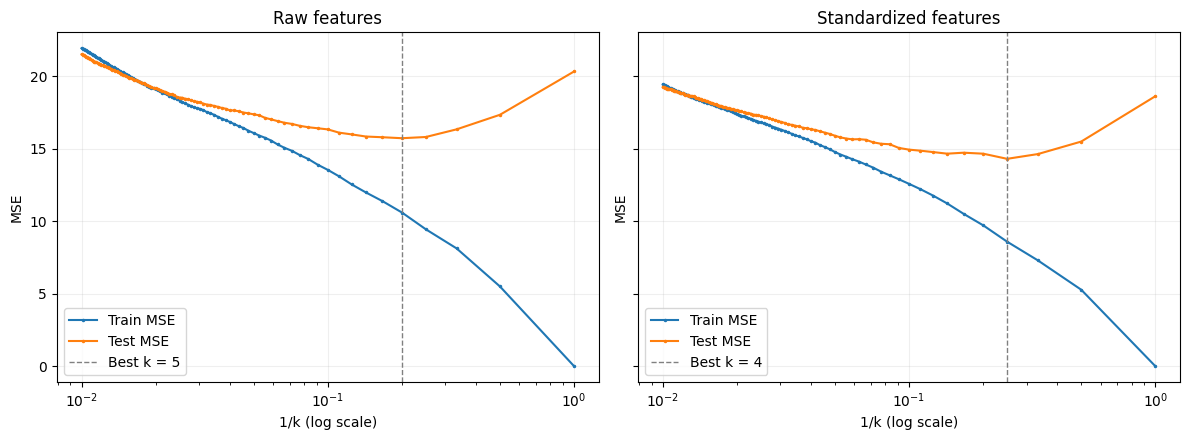

In [12]:
ks = np.arange(1, 101)
y_train = train[response]
y_test = test[response]

def knn_errors(X_train, X_test):
    train_errors, test_errors = [], []
    for k in ks:
        knn = KNeighborsRegressor(n_neighbors=k).fit(X_train, y_train)
        train_errors.append(mean_squared_error(y_train, knn.predict(X_train)))
        test_errors.append(mean_squared_error(y_test, knn.predict(X_test)))
    return np.array(train_errors), np.array(test_errors)

# raw features
raw_train_mse, raw_test_mse = knn_errors(train[predictors], test[predictors])

# normalized features (z-score, fit on the training set only)
scaler = StandardScaler().fit(train[predictors])
scaled_train_mse, scaled_test_mse = knn_errors(
    scaler.transform(train[predictors]), scaler.transform(test[predictors])
)

best_raw_k = int(ks[np.argmin(raw_test_mse)])
best_scaled_k = int(ks[np.argmin(scaled_test_mse)])
knn_summary = pd.DataFrame({
    "Best k": [best_raw_k, best_scaled_k],
    "Train MSE": [raw_train_mse[best_raw_k - 1], scaled_train_mse[best_scaled_k - 1]],
    "Test MSE": [raw_test_mse[best_raw_k - 1], scaled_test_mse[best_scaled_k - 1]],
}, index=["Raw", "Standardized"])
display(knn_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, title, train_errors, test_errors, best_k in [
    (axes[0], "Raw features", raw_train_mse, raw_test_mse, best_raw_k),
    (axes[1], "Standardized features", scaled_train_mse, scaled_test_mse, best_scaled_k),
]:
    ax.plot(1 / ks, train_errors, marker=".", markersize=3, label="Train MSE")
    ax.plot(1 / ks, test_errors, marker=".", markersize=3, label="Test MSE")
    ax.axvline(1 / best_k, color="gray", linestyle="--", linewidth=1,
               label=f"Best k = {best_k}")
    ax.set_xscale("log")
    ax.set(xlabel="1/k (log scale)", ylabel="MSE", title=title)
    ax.grid(alpha=0.2)
    ax.legend()
plt.tight_layout()
plt.show()

**Answer:** I interpret "normalized" as z-score standardization, with the means and standard deviations computed on the training set only. The best $k$ is the one with the lowest test MSE among $k=1,\ldots,100$.

| Features | Best k | Train MSE | Test MSE |
|---|---:|---:|---:|
| Raw | 5 | 10.601 | 15.727 |
| Standardized | 4 | 8.591 | 14.306 |

The curves show the usual bias–variance trade-off. Train MSE falls steadily as $1/k$ grows and reaches 0 at $k=1$, because each training point is its own nearest neighbor. Test MSE is U-shaped: large $k$ (small $1/k$) oversmooths and has high bias, while very small $k$ overfits and has high variance. The best fit is at $k=5$ with raw features and $k=4$ with standardized features.

Standardizing helps because KNN uses Euclidean distance. On the raw scale, `V` (SD ≈ 12.7) and `RH` (SD ≈ 14.6) dominate the distance, while `AT` (SD ≈ 7.5), the most predictive variable, gets less weight. After standardization, all four predictors contribute equally.

### 1(j) Question

> Compare the results of KNN Regression with the linear regression model that has the smallest test error and provide your analysis.

In [13]:
comparison = pd.DataFrame({
    "Train MSE": [
        linear_mse.loc["Selected quadratic + interactions", "Train MSE"],
        knn_summary.loc["Raw", "Train MSE"],
        knn_summary.loc["Standardized", "Train MSE"],
    ],
    "Test MSE": [
        linear_mse.loc["Selected quadratic + interactions", "Test MSE"],
        knn_summary.loc["Raw", "Test MSE"],
        knn_summary.loc["Standardized", "Test MSE"],
    ],
}, index=["Best linear model", f"Raw KNN (k={best_raw_k})",
          f"Standardized KNN (k={best_scaled_k})"])
display(comparison.round(3).sort_values("Test MSE"))

,Train MSE,Test MSE
Standardized KNN (k=4),8.591,14.306
Raw KNN (k=5),10.601,15.727
Best linear model,17.891,18.660


**Answer:** The best linear model is the selected quadratic + interaction model from 1(h).

| Model | Train MSE | Test MSE |
|---|---:|---:|
| Standardized KNN ($k=4$) | 8.591 | 14.306 |
| Raw KNN ($k=5$) | 10.601 | 15.727 |
| Best linear model | 17.891 | 18.660 |

**Analysis:**

- **KNN predicts better on this split.** Standardized KNN's test MSE is about **23% lower** than the best linear model's (14.306 vs 18.660), and even raw KNN beats the linear model.
- **Why KNN wins here:** The data set is large (6,697 training points) and low-dimensional (4 predictors), which is where a nonparametric method works well: the neighborhoods are dense, so local averaging has low variance. And as 1(c), 1(f), and 1(g) showed, the true relationship is nonlinear and has interactions. KNN can adapt to that shape automatically, while the linear model only captures the quadratic and pairwise terms we chose to add.
- **Overfitting:** KNN has a much larger gap between train and test MSE than the linear model (8.6 vs 14.3, compared with 17.9 vs 18.7), which reflects its much higher flexibility. The linear model's train and test errors are almost equal, so it generalizes very predictably.
- **Why one might still prefer linear regression:** It is interpretable (each coefficient has a meaning, and we can test hypotheses about it), it is cheap to predict with, and it can extrapolate a trend. KNN is a black box, has to store and search all the training data for every prediction, and cannot predict well outside the range of the training data.
- **Caveat:** Because $k$ was chosen by looking at the test set, KNN's reported test MSE is somewhat optimistic. A fairer comparison would choose $k$ by cross-validation on the training set only.

## 2. ISLR 2.4.1

**Question:** For each setting, should a flexible statistical learning method generally perform better or worse than an inflexible method? Explain.

**Answer:**

| Setting | Flexible method | Reason |
|---|---|---|
| (a) Very large $n$, small $p$ | Better | Ample data can support a lower-bias fit without as much variance cost. |
| (b) Very large $p$, small $n$ | Worse | Too little data relative to the number of predictors; overfitting risk is high. |
| (c) Highly nonlinear relationship | Better | Flexibility can capture the nonlinear shape and reduce bias. |
| (d) Very high error variance | Worse | A flexible fit is more likely to follow noise. |

## 3. ISLR 2.4.7

**Question:** Use the six labeled observations below to classify $(X_1,X_2,X_3)=(0,0,0)$ by Euclidean KNN. Find all distances, predict with $K=1$ and $K=3$, and explain the choice of $K$ for a highly nonlinear Bayes boundary.

| Obs. | $X_1$ | $X_2$ | $X_3$ | $Y$ | Distance to $(0,0,0)$ |
|---|---:|---:|---:|---|---:|
| 1 | 0 | 3 | 0 | Red | $3$ |
| 2 | 2 | 0 | 0 | Red | $2$ |
| 3 | 0 | 1 | 3 | Red | $\sqrt{10}$ |
| 4 | 0 | 1 | 2 | Green | $\sqrt{5}$ |
| 5 | -1 | 0 | 1 | Green | $\sqrt{2}$ |
| 6 | 1 | 1 | 1 | Red | $\sqrt{3}$ |

**Answer:**

- **(a)** $d_i=\sqrt{X_{i1}^2+X_{i2}^2+X_{i3}^2}$; distances appear in the table.
- **(b)** $K=1$: **Green** (observation 5).
- **(c)** $K=3$: **Red** (nearest are observations 5, 6, and 2: Green, Red, Red).
- **(d)** A **small $K$** gives a flexible, local boundary that can follow nonlinear structure; choose the exact value with validation.


## AI Usage：

 Used AI to review my notebook: it checked my numerical results, suggested a display change for KNN graph and formatting changes (From ： -> :)
 
 prompt:
 
 Please improve Homework 2 Question 1(i) without changing the code and numerical results. Make the train/test MSE versus 1/k plots easier to read using a log-scaled x-axis, point markers, and a vertical line at the best k. 

 On piazza a post said that all import need to be on the top, can you help me to move the import to the top?